In [2]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

yu.setpath('check_helicity_priyajit')

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
enss=['e']
ens='e'

path=f'pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)

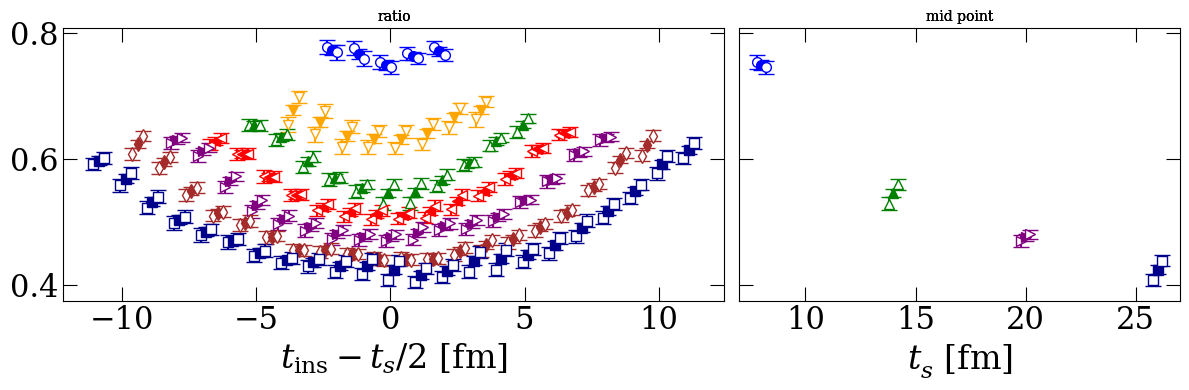

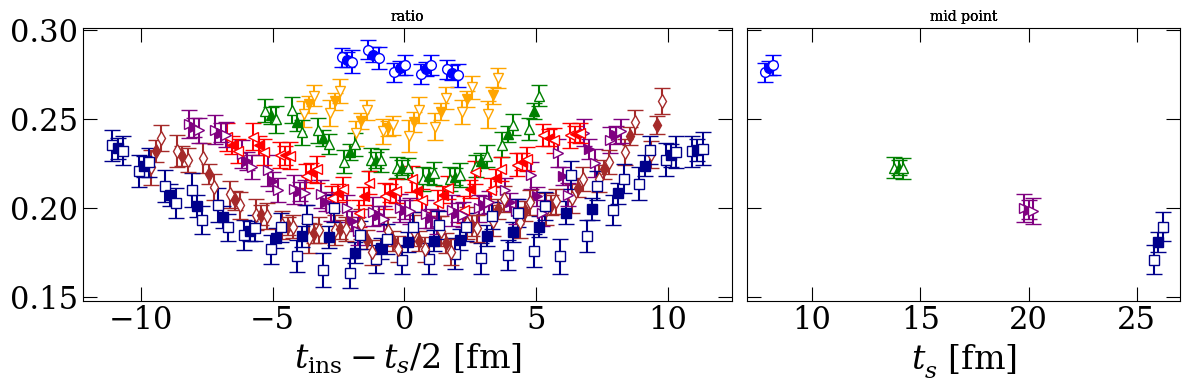

In [4]:
def run(case):
    key2tf2ratio={}
    for ens in enss:
        key2tf2ratio[(ens,'j+;conn')]={}
        key2tf2ratio[(ens,'j-;conn')]={}
        
        basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
        
        mN_jk=ens2pars_jk_meff2st[ens][:,0]
        factor_equal=1/(-3*mN_jk/4)
        factor_equal=np.mean(factor_equal)[None]
        
        path=f'{basepath}/conn_2pt_{case}.h5'
        with h5py.File(path) as f:
            moms=yu.moms2list(f['moms'])
            imom=moms.index([0,0,0])
            
            tf2c2pt={}
            for tf in f['data'].keys():
                t=f[f'data/{tf}'][:]
                t=yu.jackknife(np.real(t[:,:,imom]))
                tf2c2pt[int(tf)]=t

        path=f'{basepath}/conn_0,0,0,0,0,0_{case}.h5'
        with h5py.File(path) as f:
            moms=yu.moms2list(f['moms'])
            imom=moms.index([0,0,0,0,0,0])
            
            for jtf in f['data'].keys():
                j,tf=jtf.split('_'); tf=int(tf)
                t=f[f'data/{jtf}'][:]
                t=t[:,:,0,projs.index('P0'),inserts.index('tt')]
                c3pt=yu.jackknife(t)
                ratio=np.real(c3pt/tf2c2pt[tf][:,tf:tf+1]*factor_equal[:,None])
                key=(ens,j)
                key2tf2ratio[key][tf]=ratio
                
    ens2tfs_conn={}
    for ens in enss:
        tfs=list(key2tf2ratio[(ens,'j+;conn')].keys()); tfs.sort()
        ens2tfs_conn[ens]=tfs
        # print(ens,tfs)
        
    return key2tf2ratio, ens2tfs_conn

cases=['cfgs_conn_Giannis_fine','cfgs_conn_Giannis_bug','cfgs_conn_Giannis']

for j in ['j+;conn','j-;conn']:
    dic={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[run(cases[0])[0][('e',j)],None,None,None,None],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,2,None],
        'mfc:[global]':['white'],
        'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,None],
    }
    dic2={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[run(cases[2])[0][('e',j)],None,None,None,None],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,2,None],
        'mfc:[global]':['None'],
        'shift:[rainbow,midpoint,fit]':[0,0,None],
    }
    dic3={
        'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[run(cases[1])[0][('e',j)],None,None,None,None],
        'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,2,None],
        'mfc:[global]':['white'],
        'shift:[rainbow,midpoint,fit]':[0.2,0.2,None],
    }
    fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
    fig,axs=yu.makePlot_3pt(dic2,shows=['rainbow','midpoint'],figAxs=(fig,axs))
    fig,axs=yu.makePlot_3pt(dic3,shows=['rainbow','midpoint'],figAxs=(fig,axs))
    yu.finalizePlot()